## Import Required Libraries

In [17]:
import os
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Set Device

In [2]:
# if torch.backends.mps.is_available():
#     device = torch.device("mps")
#     print("Using Apple MPS (Metal Performance Shaders)")
# else:
device = torch.device("cpu")
print("Using CPU")

Using CPU


## Data Preprocessing and Transforms

In [3]:
# Define the transformations for training and testing

transform_train = transforms.Compose([
    transforms.Resize((256, 256)),                    # Resize to slightly larger
    transforms.RandomCrop(224),                       # Random crop for augmentation
    transforms.RandomHorizontalFlip(),                # Flip left-right (not up-down)
    transforms.Grayscale(num_output_channels=1),      # Ensure grayscale
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),                    # Direct resize to 224x224
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Load the dataset

train_dir = "chest_xray/train"
val_dir = "chest_xray/val"
test_dir = "chest_xray/test"

train_data = datasets.ImageFolder(train_dir, transform=transform_train)
val_data = datasets.ImageFolder(val_dir, transform=transform_test)
test_data = datasets.ImageFolder(test_dir, transform=transform_test)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

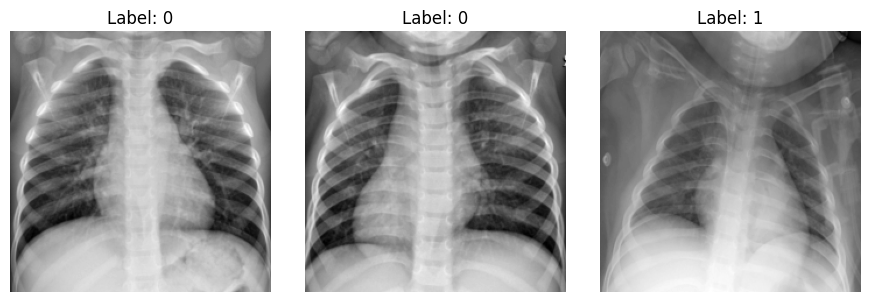

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Get one batch of preprocessed images
images, labels = next(iter(train_loader))

plt.figure(figsize=(9,3))

for i in range(3):
    img = images[i]
    
    # Unnormalize (mean=0.5, std=0.5)
    img = img * 0.5 + 0.5
    
    # Convert to numpy and remove channel dimension
    img = np.squeeze(img.numpy())
    
    plt.subplot(1, 3, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

    



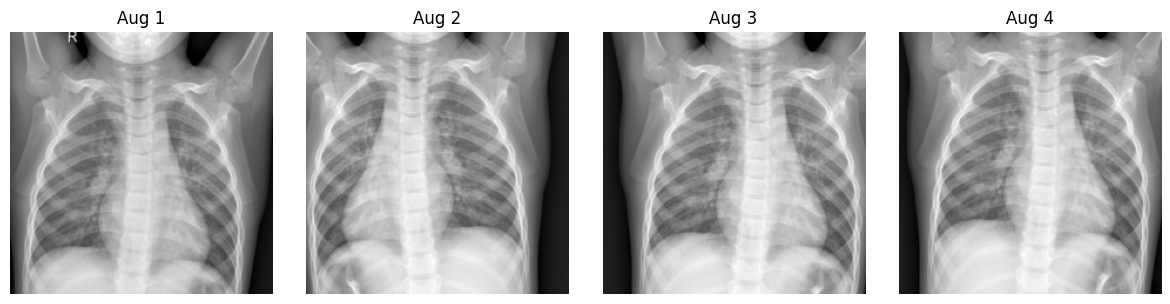

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Get one image from training dataset (before batching)
img_original, label = train_data[0]   # This already applies augmentation

plt.figure(figsize=(12,3))

for i in range(4):
    img_aug, _ = train_data[0]   # Each call applies new random augmentation
    
    # Unnormalize
    img_aug = img_aug * 0.5 + 0.5
    img_aug = np.squeeze(img_aug.numpy())
    
    plt.subplot(1, 4, i+1)
    plt.imshow(img_aug, cmap='gray')
    plt.axis("off")
    plt.title(f"Aug {i+1}")

plt.tight_layout()
plt.show()


## Visualize Data

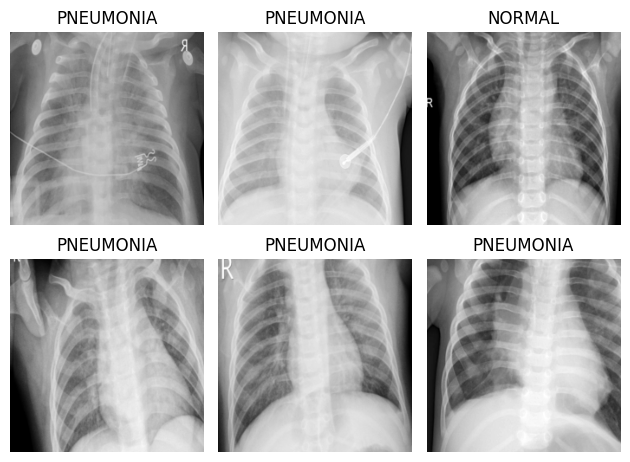

In [9]:
# Display a batch of images from the training set

classes = train_data.classes
def show_batch():
    images, labels = next(iter(train_loader))
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        img = images[i].squeeze()  # [224, 224]
        plt.imshow(img, cmap='gray')
        plt.title(classes[int(labels[i])])
        plt.axis('off')
    plt.tight_layout()
    plt.show()
show_batch()


Number of classes: 2 -> ['NORMAL', 'PNEUMONIA']
Number of images in Train: 5216
Number of images in Validation: 16
Number of images in Test: 624
Train distribution: Counter({'PNEUMONIA': 3875, 'NORMAL': 1341})
Validation distribution: Counter({'NORMAL': 8, 'PNEUMONIA': 8})
Test distribution: Counter({'PNEUMONIA': 390, 'NORMAL': 234})


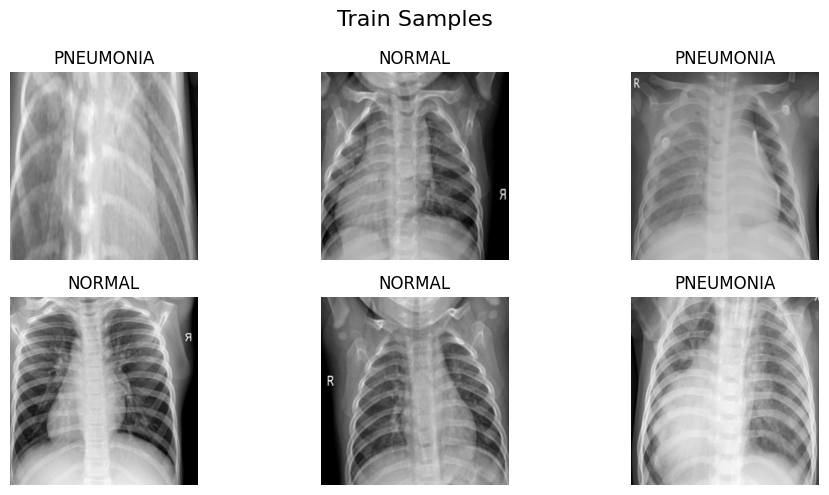

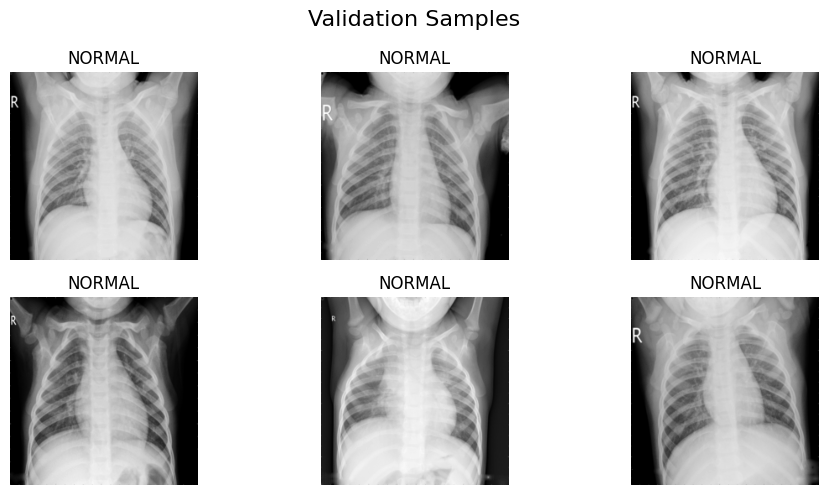

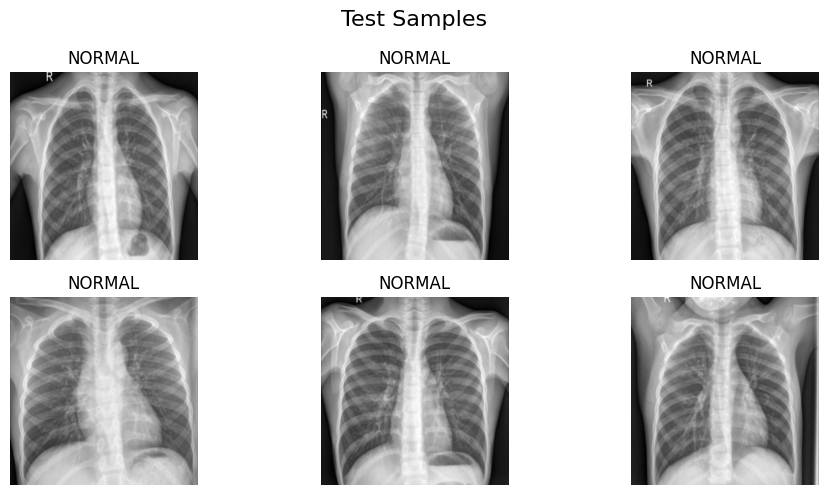

In [10]:
import matplotlib.pyplot as plt
from collections import Counter

# ----- Print dataset info -----
print(f"Number of classes: {len(train_data.classes)} -> {train_data.classes}")
print(f"Number of images in Train: {len(train_data)}")
print(f"Number of images in Validation: {len(val_data)}")
print(f"Number of images in Test: {len(test_data)}")

# Count images per class
def count_per_class(dataset):
    counts = Counter()
    for _, label in dataset:
        counts[train_data.classes[label]] += 1
    return counts

print("Train distribution:", count_per_class(train_data))
print("Validation distribution:", count_per_class(val_data))
print("Test distribution:", count_per_class(test_data))

# ----- Visualize sample images -----
def show_samples(loader, title="Sample Images"):
    images, labels = next(iter(loader))
    plt.figure(figsize=(10,5))
    for i in range(6):
        plt.subplot(2,3,i+1)
        img = images[i].squeeze()  # remove channel dimension
        plt.imshow(img, cmap='gray')
        plt.title(train_data.classes[labels[i]])
        plt.axis('off')
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

show_samples(train_loader, title="Train Samples")
show_samples(val_loader, title="Validation Samples")
show_samples(test_loader, title="Test Samples")


## Define CNN Model

In [11]:

# Load pretrained MobileNetV2
model = models.mobilenet_v2(pretrained=True)

# ---- Modify first conv layer (RGB → Grayscale) ----
model.features[0][0] = nn.Conv2d(
    in_channels=1,   # grayscale X-ray
    out_channels=32,
    kernel_size=3,
    stride=2,
    padding=1,
    bias=False
)

# ---- Replace classifier head ----
model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(model.last_channel, 1)  # binary output
)

model = model.to(device)


d:\1.pneumoNet\.venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\1.pneumoNet\.venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Loss, Optimizer

In [12]:
normal_count = 1341 # Number of normal images in the training set
pneumonia_count = 3875 # Number of pneumonia images in the training set

# Calculate the positive weight for the loss function

pos_weight = torch.tensor([normal_count / pneumonia_count]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Training Loop

In [13]:
model = models.mobilenet_v2(pretrained=True)

# Modify first conv for grayscale
model.features[0][0] = nn.Conv2d(
    in_channels=1,
    out_channels=32,
    kernel_size=3,
    stride=2,
    padding=1,
    bias=False
)

# Replace classifier
model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(model.last_channel, 1)
)

model = model.to(device)


In [14]:
epochs = 4

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1} done")


Epoch 1 done
Epoch 2 done
Epoch 3 done
Epoch 4 done


## Evaluation

In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        # Convert logits → probabilities
        probs = torch.sigmoid(outputs)

        # Threshold (standard = 0.5)
        preds = (probs >= 0.5).int()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)


Confusion Matrix:
 [[201  33]
 [ 13 377]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.94      0.86      0.90       234
   PNEUMONIA       0.92      0.97      0.94       390

    accuracy                           0.93       624
   macro avg       0.93      0.91      0.92       624
weighted avg       0.93      0.93      0.93       624



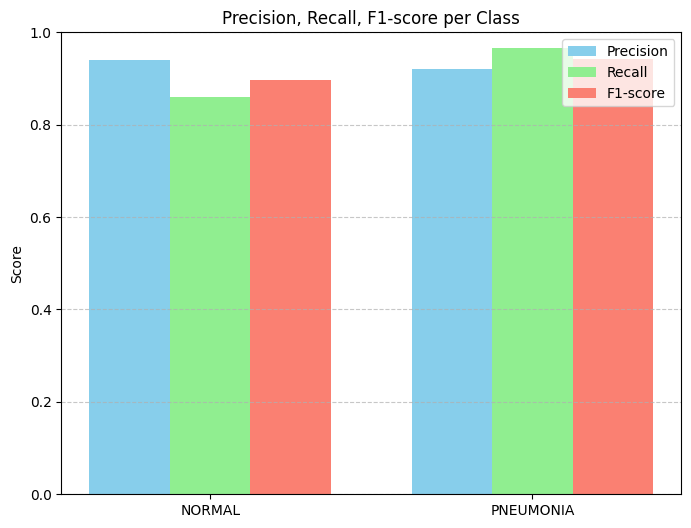

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

# --- Make sure you already have all_labels and all_preds from evaluation ---
# all_labels = true labels, all_preds = predicted labels (0 or 1)

# Compute precision, recall, f1-score per class
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, labels=[0,1]  # 0: NORMAL, 1: PNEUMONIA
)

classes = ["NORMAL", "PNEUMONIA"]
x = np.arange(len(classes))  # label locations

width = 0.25  # bar width

plt.figure(figsize=(8,6))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1, width, label='F1-score', color='salmon')

plt.xticks(x, classes)
plt.ylim([0,1])
plt.ylabel("Score")
plt.title("Precision, Recall, F1-score per Class")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


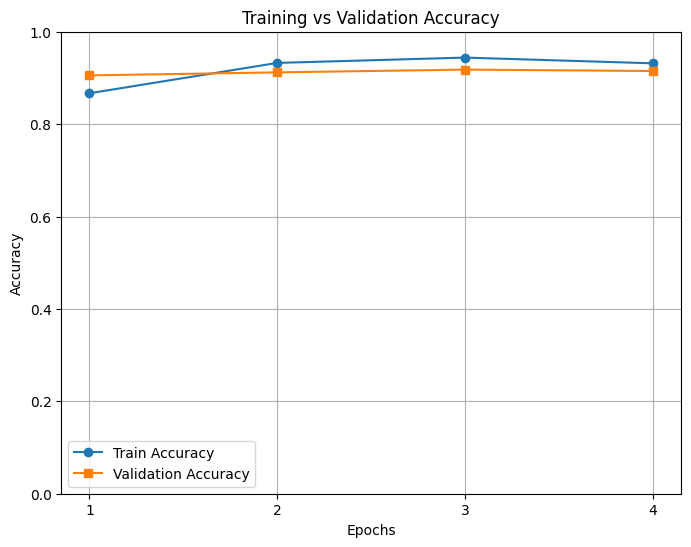

In [15]:
import matplotlib.pyplot as plt

# Example: Replace with your actual saved lists
# If you saved during training, load them here instead
train_accuracies = [0.8668, 0.9325, 0.9440, 0.9316]  # from your training logs
val_accuracies = [0.9055, 0.9120, 0.9180, 0.9150]    # replace with your validation logs

epochs = len(train_accuracies)

plt.figure(figsize=(8,6))
plt.plot(range(1, epochs+1), train_accuracies, marker='o', label='Train Accuracy')
plt.plot(range(1, epochs+1), val_accuracies, marker='s', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xticks(range(1, epochs+1))
plt.ylim([0, 1])
plt.grid(True)
plt.legend()
plt.show()


## Saving the model

In [9]:
os.makedirs("backend/saved_models", exist_ok=True)

torch.save(model.state_dict(), "backend/saved_models/pneumonia_cnn.pth")
print("Model saved successfully at backend/saved_models/pneumonia_cnn.pth")

Model saved successfully at backend/saved_models/pneumonia_cnn.pth
